# **Regresion con Bootstrap**

> **Dataset:** `datosestresyansiedad.xlsx` — 1 200 estudiantes, 12 variables predictoras, objetivo: `stress_level` (1–10).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
# ── Cargar datos ──────────────────────────────────────────────────────────────

df_raw = pd.read_excel('datosestresyansiedad.xlsx')

# Codificar variables categóricas
le = LabelEncoder()
df_raw['gender_enc']   = le.fit_transform(df_raw['gender'])
df_raw['platform_enc'] = le.fit_transform(df_raw['platform_usage'])
df_raw['social_enc']   = le.fit_transform(df_raw['social_interaction_level'])

features = [
    'age', 'gender_enc', 'daily_social_media_hours', 'platform_enc',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_enc', 'anxiety_level',
    'addiction_level', 'depression_label'
]
nombres = [
    'Edad', 'Género', 'Hrs. Redes', 'Plataforma',
    'Hrs. Sueño', 'Pantalla/dormir', 'Desempeño Acad.',
    'Act. Física', 'Inter. Social', 'Ansiedad',
    'Adicción', 'Depresión'
]

df = df_raw[features].copy()
df.columns = nombres
df['stress_level'] = df_raw['stress_level'].values

X = df[nombres].values
y = df['stress_level'].values

print(f"Shape: {df.shape}")
df.head()

Shape: (1200, 13)


,Edad,Género,Hrs. Redes,Plataforma,Hrs. Sueño,Pantalla/dormir,Desempeño Acad.,Act. Física,Inter. Social,Ansiedad,Adicción,Depresión,stress_level
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,1,0,2
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,1,10,0,8
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,4,2,0,2
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,7,9,0,1
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,5,2,0,3


In [ ]:
X[:5]

array([[14.  ,  1.  ,  7.9 ,  1.  ,  7.4 ,  2.9 ,  3.01,  1.5 ,  1.  ,
         2.  ,  1.  ,  0.  ],
       [19.  ,  0.  ,  1.9 ,  2.  ,  8.  ,  2.9 ,  3.22,  0.8 ,  0.  ,
         1.  , 10.  ,  0.  ],
       [17.  ,  0.  ,  1.3 ,  1.  ,  7.6 ,  0.5 ,  3.92,  0.  ,  0.  ,
         4.  ,  2.  ,  0.  ],
       [15.  ,  1.  ,  7.4 ,  2.  ,  6.9 ,  1.6 ,  3.48,  0.8 ,  2.  ,
         7.  ,  9.  ,  0.  ],
       [15.  ,  0.  ,  4.7 ,  0.  ,  4.9 ,  3.  ,  2.37,  1.4 ,  2.  ,
         5.  ,  2.  ,  0.  ]])

In [ ]:
model_base = LinearRegression()
model_base.fit(X, y)

print("=== Modelo Base ===")
print(f"Intercepto : {model_base.intercept_:.4f}")
for i, coef in enumerate(model_base.coef_):
    print(f"  β{i+1:02d} ({nombres[i]:<18}): {coef:.4f}")
print(f"R²         : {r2_score(y, model_base.predict(X)):.4f}")

=== Modelo Base ===
Intercepto : 5.9878
  β01 (Edad              ): -0.0483
  β02 (Género            ): 0.0706
  β03 (Hrs. Redes        ): -0.0002
  β04 (Plataforma        ): -0.1411
  β05 (Hrs. Sueño        ): 0.0467
  β06 (Pantalla/dormir   ): -0.0110
  β07 (Desempeño Acad.   ): -0.0109
  β08 (Act. Física       ): 0.0678
  β09 (Inter. Social     ): -0.0311
  β10 (Ansiedad          ): -0.0119
  β11 (Adicción          ): 0.0056
  β12 (Depresión         ): 3.2663
R²         : 0.0328


## Bootstrap para coeficientes

In [ ]:
N_BOOTSTRAP = 1000

coefs_boot      = []
intercepts_boot = []
r2_boot         = []

for _ in range(N_BOOTSTRAP):
    # Remuestreo con reemplazo
    X_res, y_res = resample(X, y, random_state=None)

    model = LinearRegression()
    model.fit(X_res, y_res)

    coefs_boot.append(model.coef_)
    intercepts_boot.append(model.intercept_)
    r2_boot.append(r2_score(y_res, model.predict(X_res)))

coefs_boot      = np.array(coefs_boot)        # shape: (1000, 12)
intercepts_boot = np.array(intercepts_boot)
r2_boot         = np.array(r2_boot)

In [ ]:
alpha = 0.05

print("\n=== Intervalos de Confianza Bootstrap (95%) ===")
print(f"{'Variable':<20} {'Estimado':>10} {'IC Inf':>10} {'IC Sup':>10}")
print("-" * 53)

# Intercepto
ic_inf = np.percentile(intercepts_boot, 2.5)
ic_sup = np.percentile(intercepts_boot, 97.5)
print(f"{'Intercepto':<20} {model_base.intercept_:>10.4f} {ic_inf:>10.4f} {ic_sup:>10.4f}")

# Coeficientes
for i, nombre in enumerate(nombres):
    ic_inf = np.percentile(coefs_boot[:, i], 2.5)
    ic_sup = np.percentile(coefs_boot[:, i], 97.5)
    print(f"{nombre:<20} {model_base.coef_[i]:>10.4f} {ic_inf:>10.4f} {ic_sup:>10.4f}")

print(f"\nR² promedio bootstrap: {r2_boot.mean():.4f} ± {r2_boot.std():.4f}")


=== Intervalos de Confianza Bootstrap (95%) ===
Variable               Estimado     IC Inf     IC Sup
-----------------------------------------------------
Intercepto               5.9878     4.1374     7.8651
Edad                    -0.0483    -0.1282     0.0300
Género                   0.0706    -0.2322     0.4111
Hrs. Redes              -0.0002    -0.0861     0.0839
Plataforma              -0.1411    -0.3472     0.0459
Hrs. Sueño               0.0467    -0.0722     0.1628
Pantalla/dormir         -0.0110    -0.2444     0.2162
Desempeño Acad.         -0.0109    -0.3040     0.2749
Act. Física              0.0678    -0.1953     0.3316
Inter. Social           -0.0311    -0.2188     0.1871
Ansiedad                -0.0119    -0.0754     0.0468
Adicción                 0.0056    -0.0549     0.0614
Depresión                3.2663     2.6544     3.8387

R² promedio bootstrap: 0.0417 ± 0.0085


## Visualización de distribuciones bootstrap

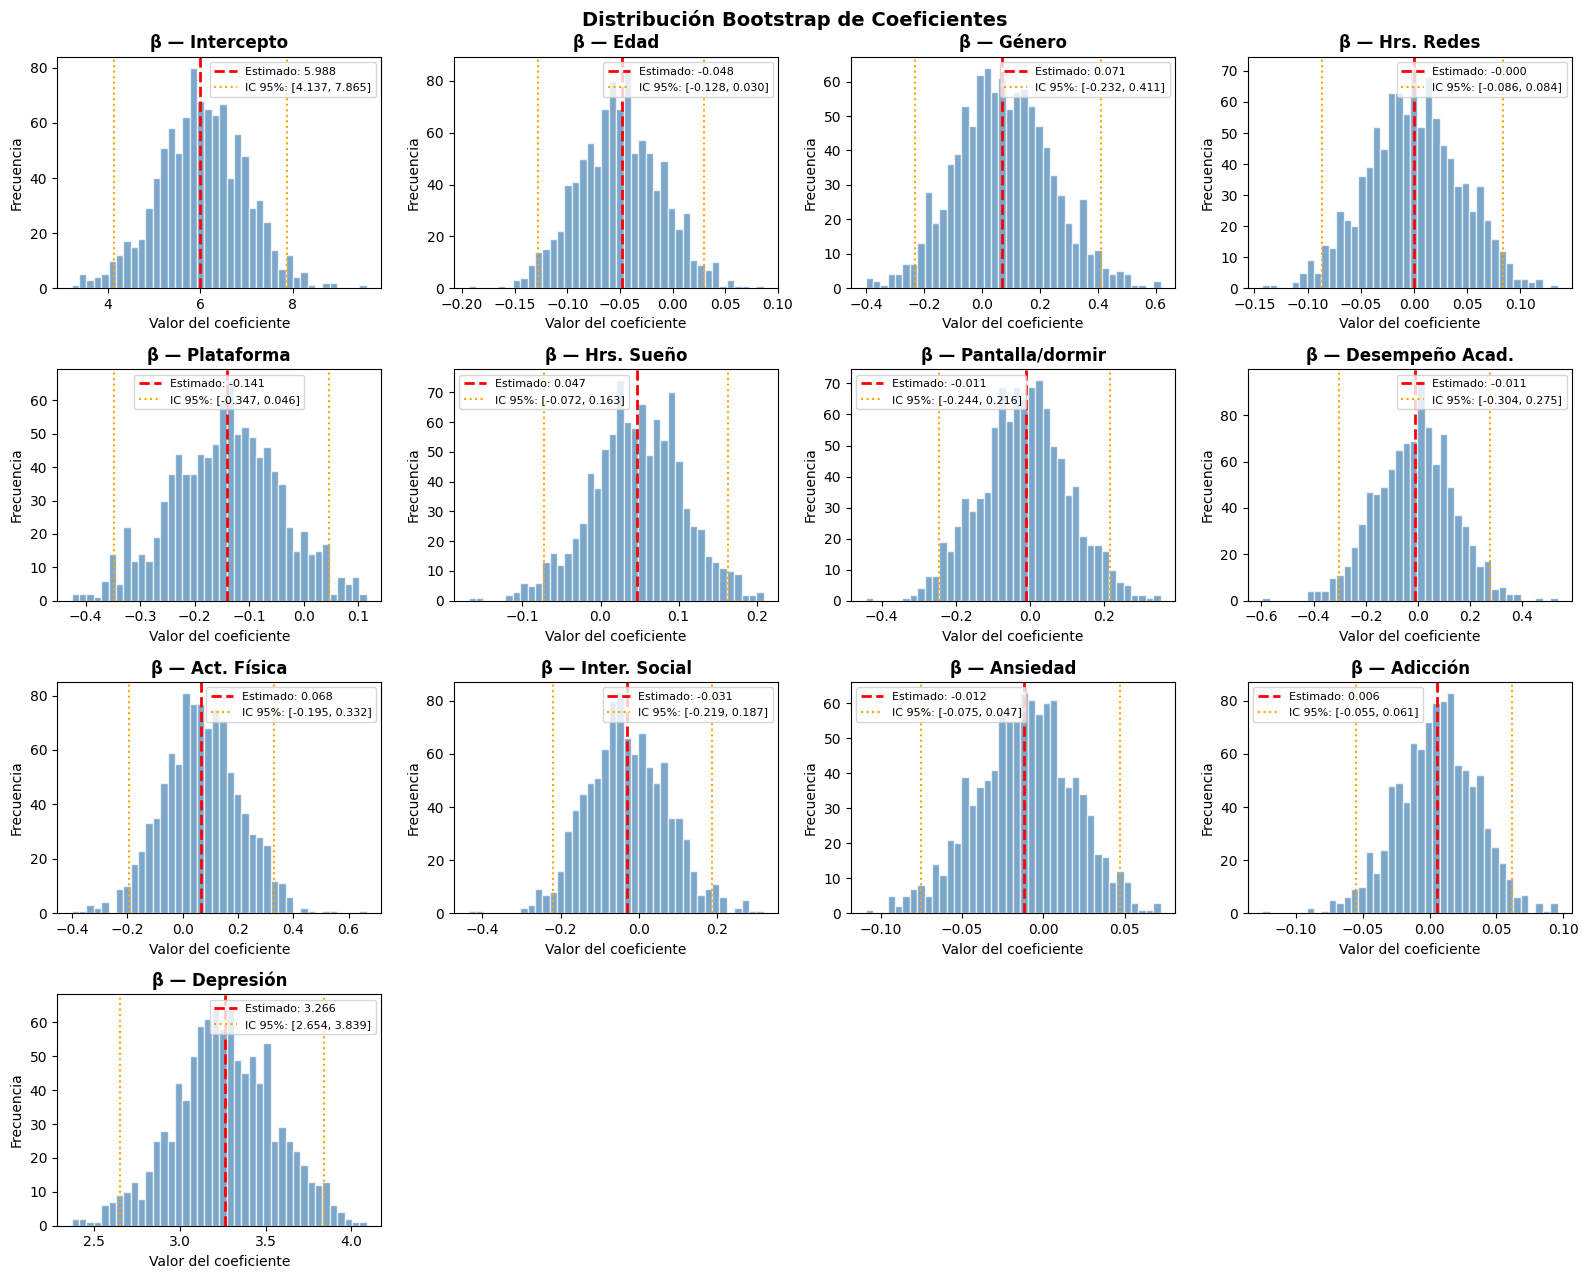

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
fig.suptitle("Distribución Bootstrap de Coeficientes", fontsize=14, fontweight='bold')

variables    = ['Intercepto'] + nombres
datos        = [intercepts_boot] + [coefs_boot[:, i] for i in range(len(nombres))]
valores_base = [model_base.intercept_] + list(model_base.coef_)

for ax, var, data, val_base in zip(axes.flatten()[:13], variables, datos, valores_base):
    ic_inf = np.percentile(data, 2.5)
    ic_sup = np.percentile(data, 97.5)

    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(val_base, color='red',    lw=2,   linestyle='--', label=f'Estimado: {val_base:.3f}')
    ax.axvline(ic_inf,  color='orange', lw=1.5, linestyle=':', label=f'IC 95%: [{ic_inf:.3f}, {ic_sup:.3f}]')
    ax.axvline(ic_sup,  color='orange', lw=1.5, linestyle=':')
    ax.set_title(f'β — {var}', fontweight='bold')
    ax.set_xlabel('Valor del coeficiente')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

for ax in axes.flatten()[13:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### 1 · Intervalos de confianza al 95% — tabla con significancia

In [ ]:
filas = []

lo = np.percentile(intercepts_boot, 2.5)
hi = np.percentile(intercepts_boot, 97.5)
filas.append({'Variable': 'Intercepto',
              'β Estimado': round(model_base.intercept_, 4),
              'IC Inf 95%': round(lo, 4),
              'IC Sup 95%': round(hi, 4),
              'Significativo': '✅ Sí' if not (lo <= 0 <= hi) else '❌ No'})

for i, nombre in enumerate(nombres):
    lo = np.percentile(coefs_boot[:, i], 2.5)
    hi = np.percentile(coefs_boot[:, i], 97.5)
    filas.append({'Variable': nombre,
                  'β Estimado': round(model_base.coef_[i], 4),
                  'IC Inf 95%': round(lo, 4),
                  'IC Sup 95%': round(hi, 4),
                  'Significativo': '✅ Sí' if not (lo <= 0 <= hi) else '❌ No'})

tabla_ic = pd.DataFrame(filas)
print(f"R² promedio bootstrap: {r2_boot.mean():.4f} ± {r2_boot.std():.4f}")
tabla_ic

R² promedio bootstrap: 0.0417 ± 0.0085


,Variable,β Estimado,IC Inf 95%,IC Sup 95%,Significativo
0,Intercepto,5.9878,4.1374,7.8651,✅ Sí
1,Edad,-0.0483,-0.1282,0.0300,❌ No
2,Género,0.0706,-0.2322,0.4111,❌ No
3,Hrs. Redes,-0.0002,-0.0861,0.0839,❌ No
4,Plataforma,-0.1411,-0.3472,0.0459,❌ No
5,Hrs. Sueño,0.0467,-0.0722,0.1628,❌ No
6,Pantalla/dormir,-0.0110,-0.2444,0.2162,❌ No
7,Desempeño Acad.,-0.0109,-0.3040,0.2749,❌ No
8,Act. Física,0.0678,-0.1953,0.3316,❌ No
9,Inter. Social,-0.0311,-0.2188,0.1871,❌ No


### 2 · Forest Plot — todos los IC en un solo gráfico

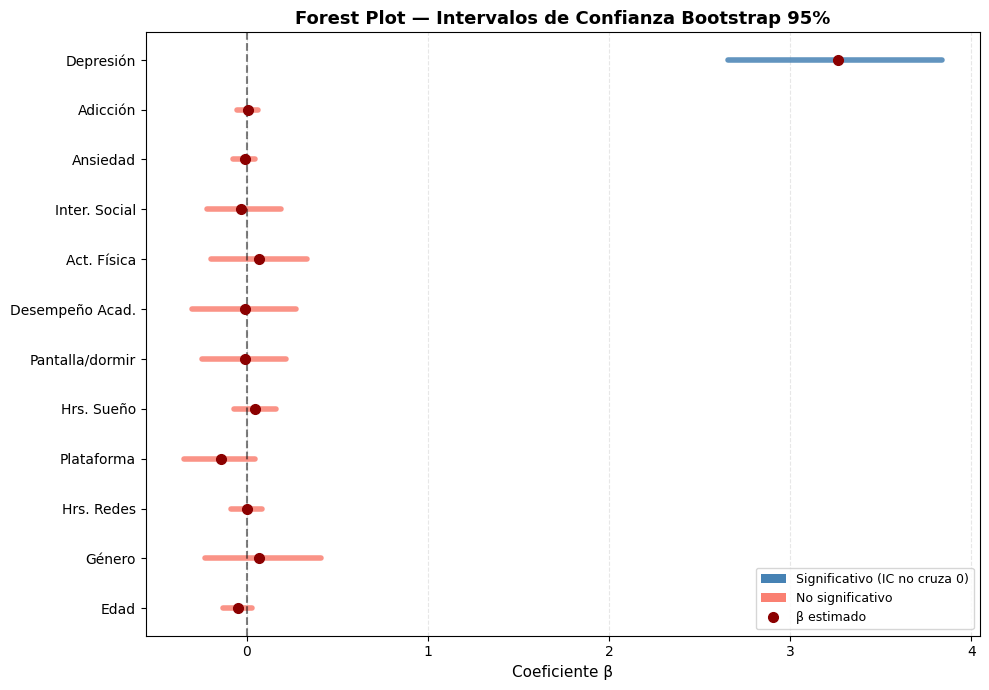

In [ ]:
from matplotlib.patches import Patch

ic_infs = [np.percentile(coefs_boot[:, i], 2.5)  for i in range(len(nombres))]
ic_sups = [np.percentile(coefs_boot[:, i], 97.5) for i in range(len(nombres))]

fig, ax = plt.subplots(figsize=(10, 7))

for i, (nombre, val, lo, hi) in enumerate(zip(nombres, model_base.coef_, ic_infs, ic_sups)):
    sig   = not (lo <= 0 <= hi)
    color = 'steelblue' if sig else 'salmon'
    ax.plot([lo, hi], [i, i], color=color, lw=4, solid_capstyle='round', alpha=0.85)
    ax.plot(val, i, 'o', color='darkred', ms=7, zorder=5)

ax.axvline(0, color='black', lw=1.5, linestyle='--', alpha=0.5, label='β = 0')
ax.set_yticks(range(len(nombres)))
ax.set_yticklabels(nombres, fontsize=10)
ax.set_xlabel('Coeficiente β', fontsize=11)
ax.set_title('Forest Plot — Intervalos de Confianza Bootstrap 95%', fontsize=13, fontweight='bold')

legend_elements = [
    Patch(facecolor='steelblue', label='Significativo (IC no cruza 0)'),
    Patch(facecolor='salmon',    label='No significativo'),
    plt.Line2D([0],[0], marker='o', color='darkred', lw=0, ms=7, label='β estimado')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 3 · Distribución del R² Bootstrap y Real vs Predicho

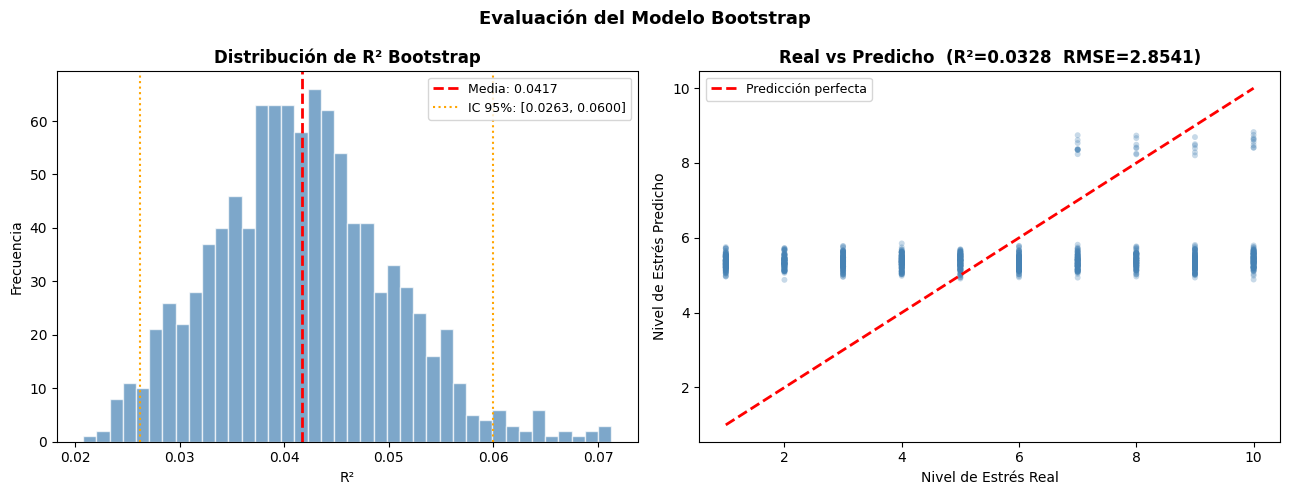

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluación del Modelo Bootstrap', fontsize=13, fontweight='bold')

# R² Bootstrap
ax = axes[0]
ax.hist(r2_boot, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(r2_boot.mean(), color='red',    lw=2,   linestyle='--',
           label=f'Media: {r2_boot.mean():.4f}')
ax.axvline(np.percentile(r2_boot, 2.5),  color='orange', lw=1.5, linestyle=':')
ax.axvline(np.percentile(r2_boot, 97.5), color='orange', lw=1.5, linestyle=':',
           label=f'IC 95%: [{np.percentile(r2_boot,2.5):.4f}, {np.percentile(r2_boot,97.5):.4f}]')
ax.set_title('Distribución de R² Bootstrap', fontweight='bold')
ax.set_xlabel('R²')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# Real vs Predicho
y_pred = model_base.predict(X)
ax = axes[1]
ax.scatter(y, y_pred, alpha=0.3, s=18, color='steelblue', edgecolors='none')
mn, mx = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], color='red', lw=2, linestyle='--', label='Predicción perfecta')
ax.set_xlabel('Nivel de Estrés Real')
ax.set_ylabel('Nivel de Estrés Predicho')
ax.set_title(f'Real vs Predicho  (R²={r2_score(y,y_pred):.4f}  RMSE={np.sqrt(mean_squared_error(y,y_pred)):.4f})',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4 · Heatmap de correlaciones

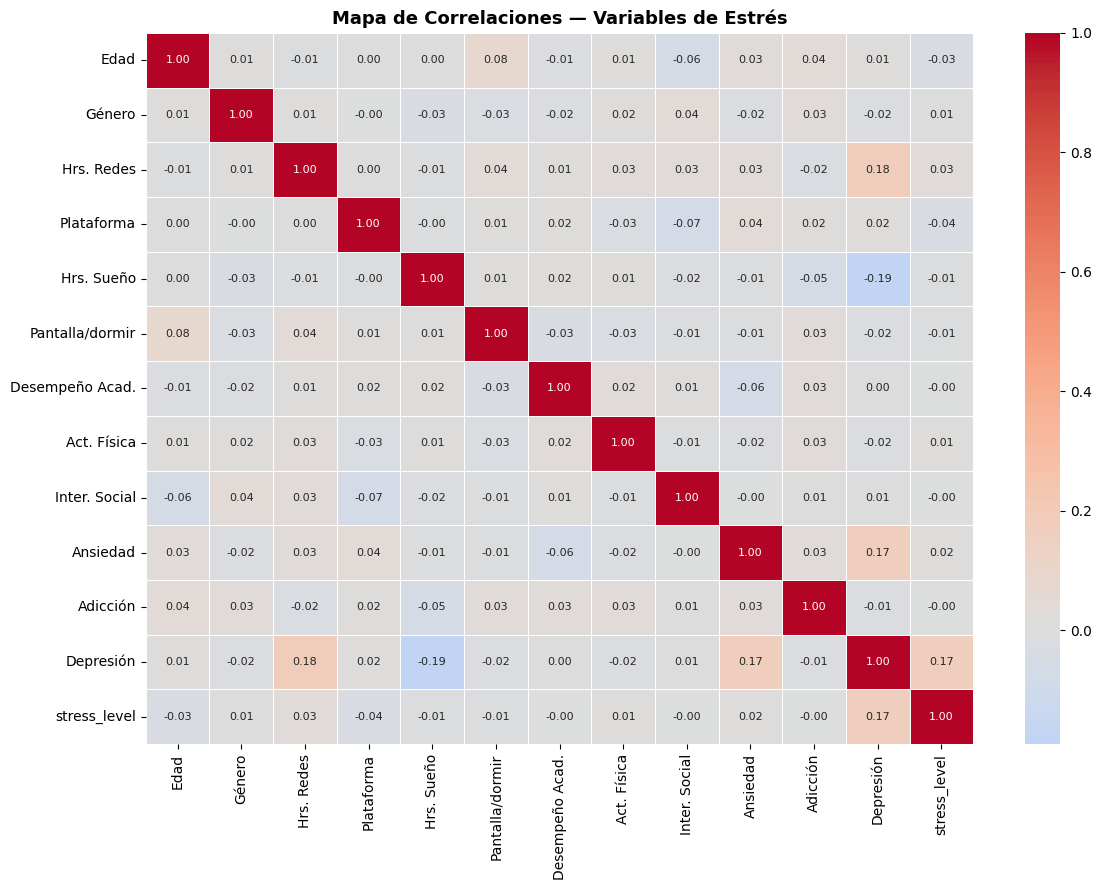

In [ ]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Mapa de Correlaciones — Variables de Estrés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5 · Análisis de residuos

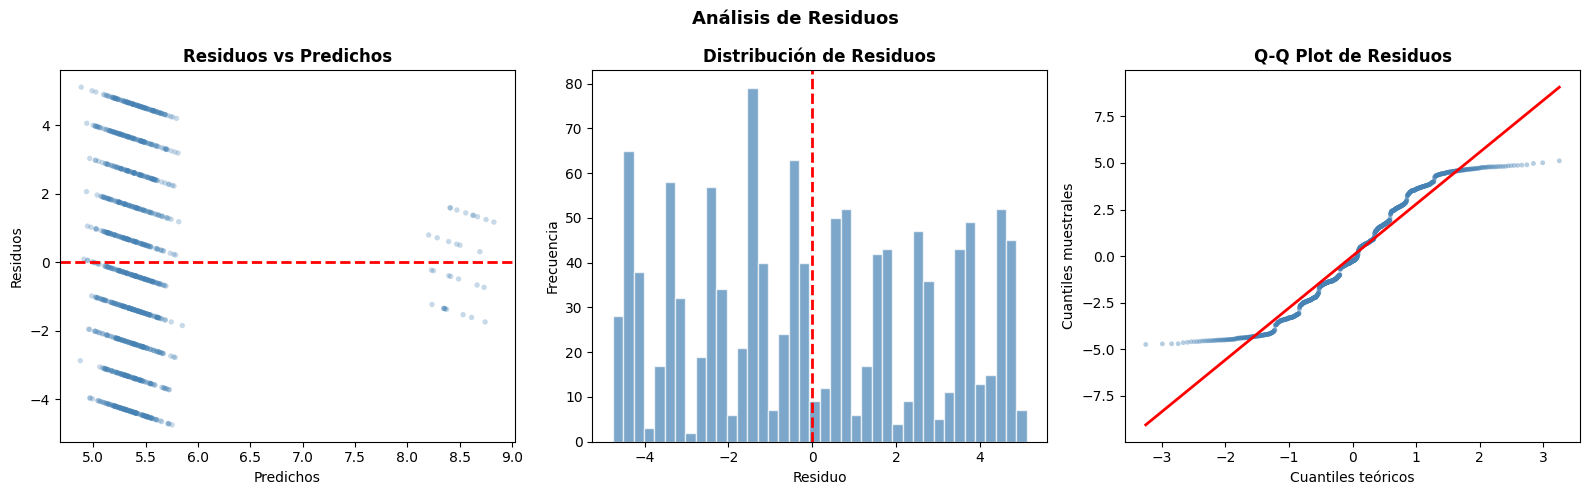

Media residuos  : -0.000000
Std  residuos   : 2.8541
Shapiro-Wilk (n=200): W=0.9422, p=0.0000  → no normal


In [ ]:
from scipy import stats

residuos = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Residuos', fontsize=13, fontweight='bold')

# Residuos vs predichos
axes[0].scatter(y_pred, residuos, alpha=0.3, s=15, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='red', lw=2, linestyle='--')
axes[0].set_xlabel('Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos', fontweight='bold')

# Histograma de residuos
axes[1].hist(residuos, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos', fontweight='bold')

# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[2].scatter(osm, osr, alpha=0.4, s=12, color='steelblue', edgecolors='none')
axes[2].plot(osm, slope*np.array(osm)+intercept, color='red', lw=2)
axes[2].set_xlabel('Cuantiles teóricos')
axes[2].set_ylabel('Cuantiles muestrales')
axes[2].set_title('Q-Q Plot de Residuos', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Media residuos  : {residuos.mean():.6f}")
print(f"Std  residuos   : {residuos.std():.4f}")
stat, p = stats.shapiro(residuos[:200])
print(f"Shapiro-Wilk (n=200): W={stat:.4f}, p={p:.4f}  {'→ normalidad ok' if p > 0.05 else '→ no normal'}")

### 6 · Estabilidad de coeficientes — Boxplot bootstrap

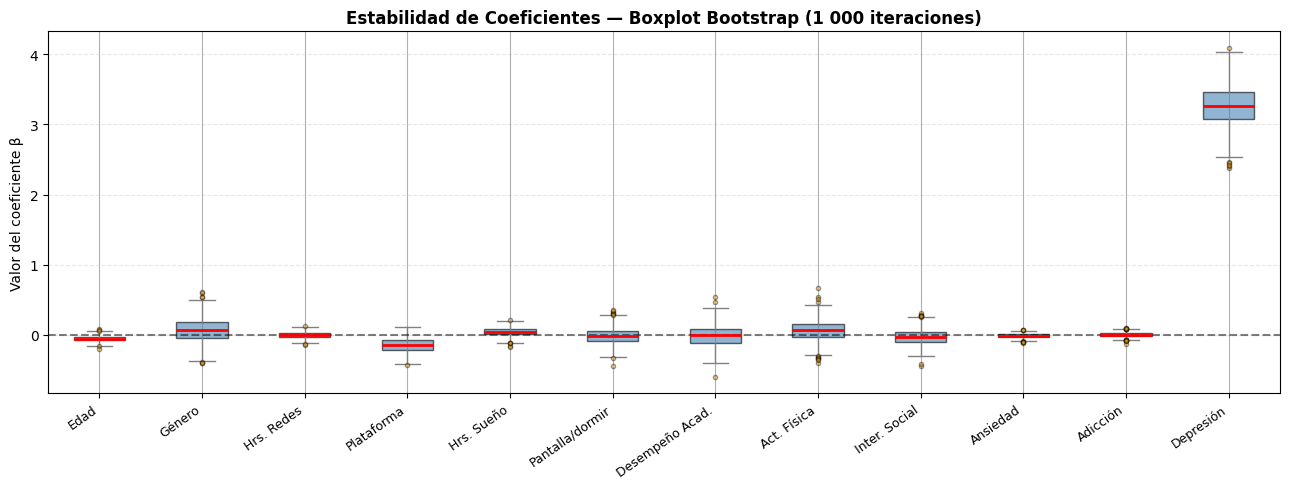

In [ ]:
df_coefs = pd.DataFrame(coefs_boot, columns=nombres)

fig, ax = plt.subplots(figsize=(13, 5))
df_coefs.boxplot(ax=ax, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='red', lw=2),
                 whiskerprops=dict(color='gray'),
                 capprops=dict(color='gray'),
                 flierprops=dict(marker='o', markerfacecolor='orange', ms=3, alpha=0.4))
ax.axhline(0, color='black', lw=1.5, linestyle='--', alpha=0.5)
ax.set_xticklabels(nombres, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Valor del coeficiente β')
ax.set_title('Estabilidad de Coeficientes — Boxplot Bootstrap (1 000 iteraciones)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

- No asume normalidad en los residuos

- Funciona bien con muestras pequeñas

- Detecta coeficientes inestables (IC muy amplios = variable poco confiable)

- Más robusto ante outliers que los IC clásicos de OLS

**Intervalos de confianza al 95%**

De las 12 variables, solo **Depresión** tiene un IC que no cruza el cero (β ≈ 3.27), lo que la convierte en el único predictor robusto del nivel de estrés en un modelo lineal. El R² bajo (~0.03) sugiere que un modelo no lineal (Random Forest, XGBoost) capturaría mejor la complejidad del fenómeno.